#### Sección 3

**Conjuntos de datos del vino**

In [109]:
import pandas as pd
from sklearn.datasets import load_wine
dataset = load_wine()
df = pd.DataFrame(data=dataset["data"], columns=dataset["feature_names"])
df["target"] = dataset["target"]
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [325]:
df.describe()
# df.info()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [114]:
df[df['target']==0].describe()

df.groupby(['target']).count()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
target,,,,,,,,,,,,,
0,59,59,59,59,59,59,59,59,59,59,59,59,59
1,71,71,71,71,71,71,71,71,71,71,71,71,71
2,48,48,48,48,48,48,48,48,48,48,48,48,48


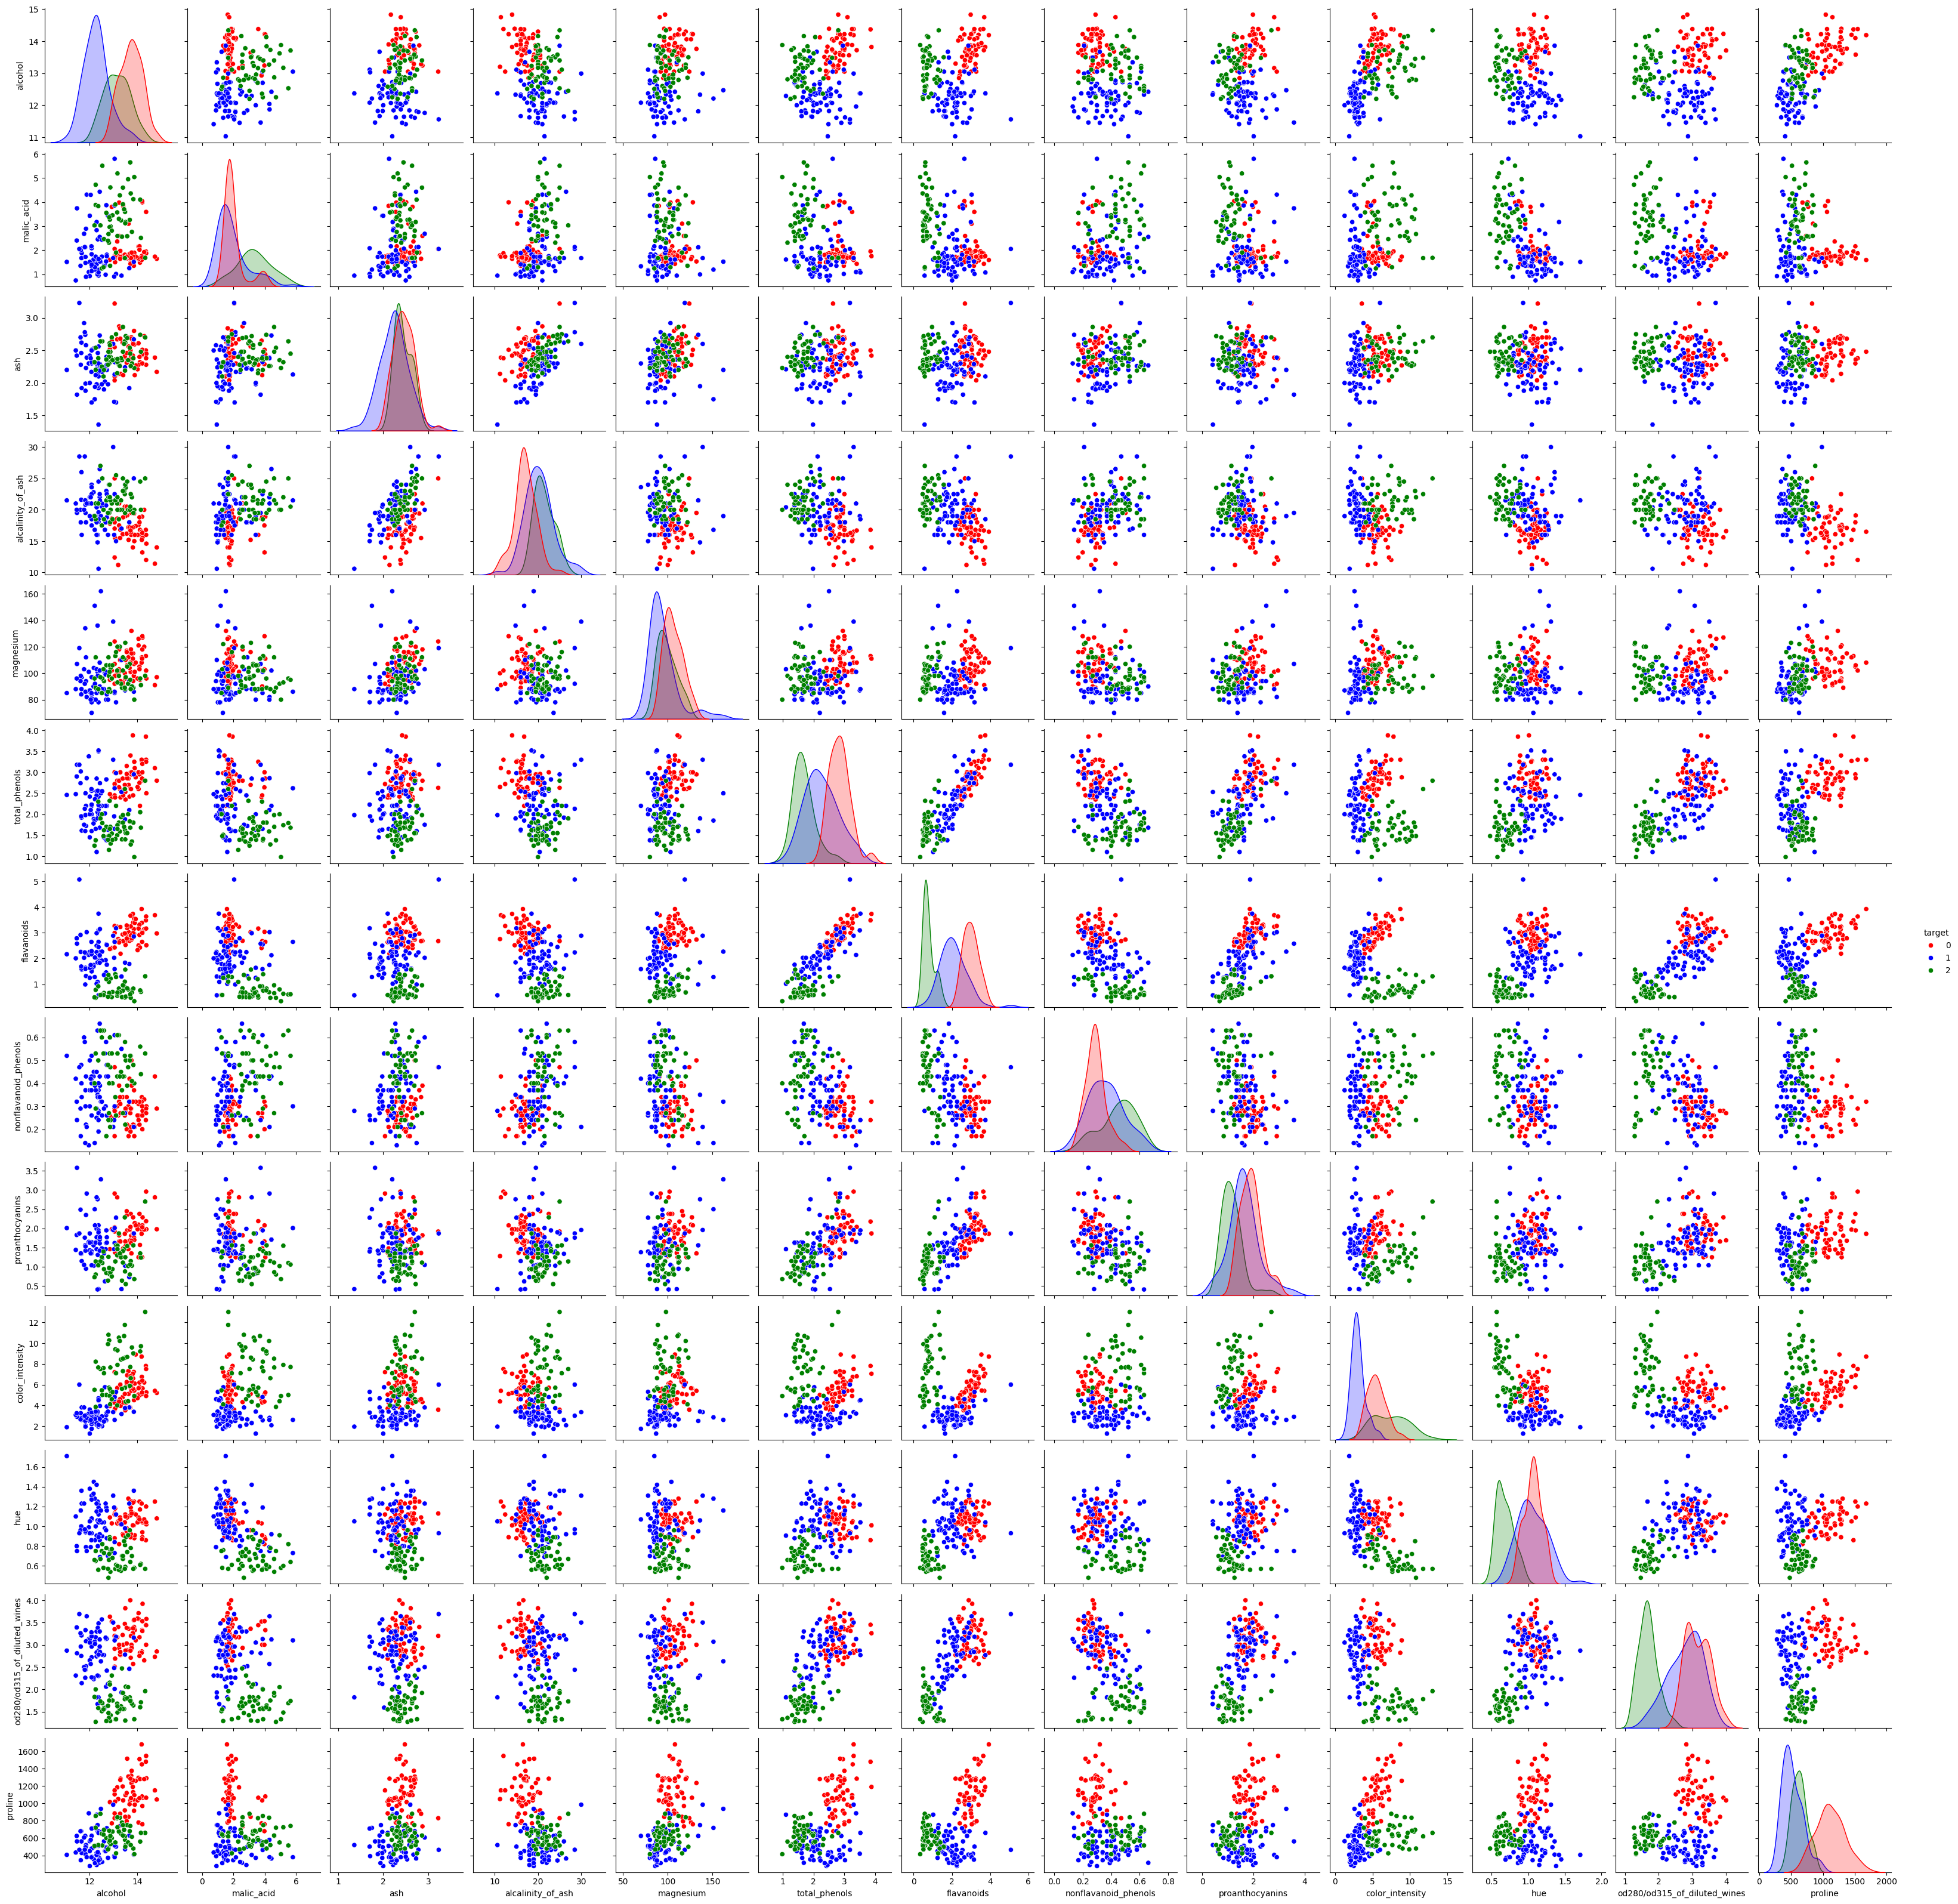

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
custom_palette = {0: "red", 1: "blue", 2: "green"}
sns.pairplot(df, hue="target", palette=custom_palette)
plt.show()

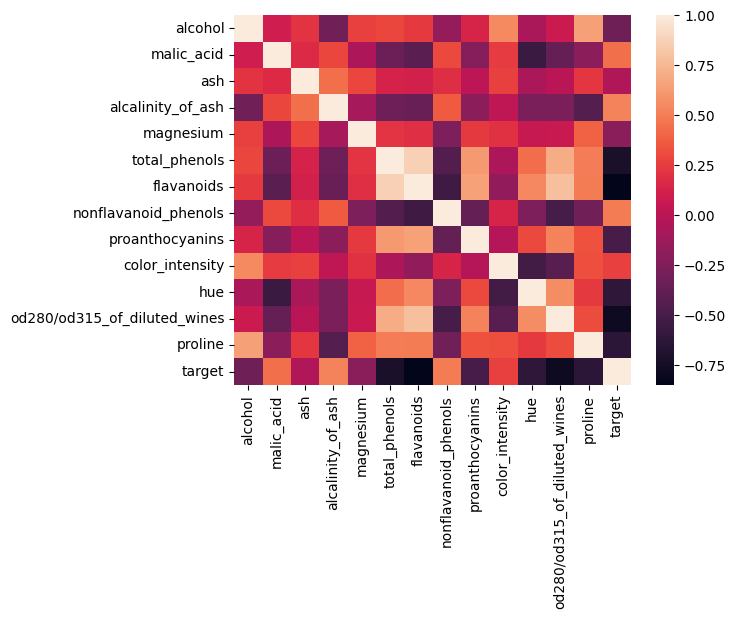

In [6]:
sns.heatmap(df.corr())
plt.show()

In [7]:
df.corr()['target'].sort_values(ascending=False, key = lambda x: abs(x))

target                          1.000000
flavanoids                     -0.847498
od280/od315_of_diluted_wines   -0.788230
total_phenols                  -0.719163
proline                        -0.633717
hue                            -0.617369
alcalinity_of_ash               0.517859
proanthocyanins                -0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                        -0.328222
color_intensity                 0.265668
magnesium                      -0.209179
ash                            -0.049643
Name: target, dtype: float64

#### Sección 5

**Construyendo el árbol de decisión**

In [131]:
from sklearn.tree import DecisionTreeClassifier
X = dataset["data"]
y = dataset["target"]

clf = DecisionTreeClassifier()
clf.fit(X, y)

DecisionTreeClassifier()

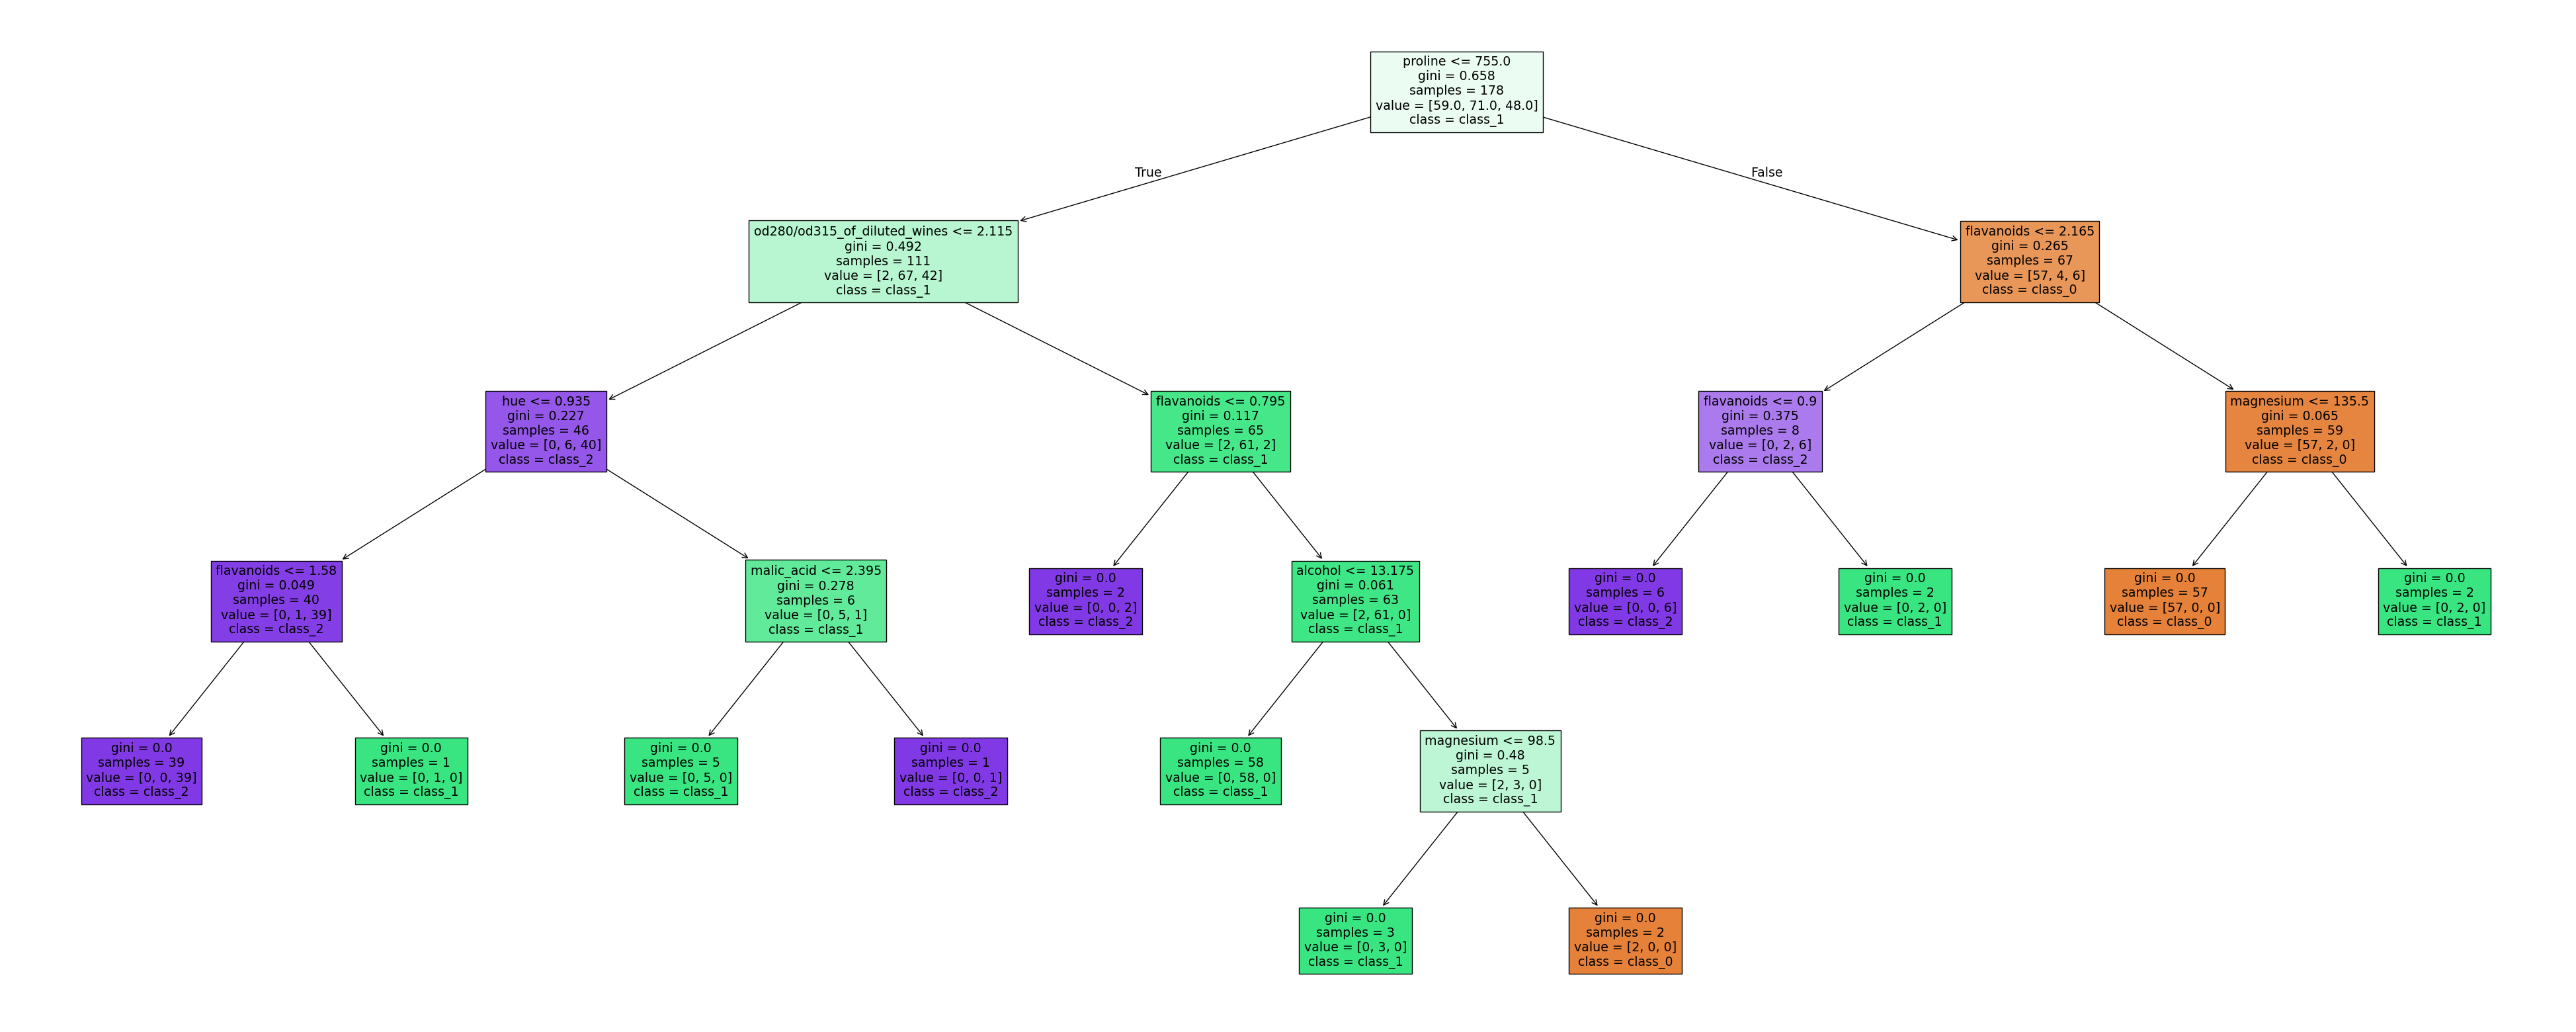

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(50, 20))
plot_tree(clf, feature_names=dataset["feature_names"],
          class_names=dataset["target_names"], filled=True)
plt.show()

### Sección 6

**Predicciones**

In [132]:
y_pred = clf.predict(X)

from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

1.0

### Tarea 6

**En la presente entrega se hará uso de una semilla para la reproducibilidad de los resultados ya que se estará comparando resultados de distintas ejecuciones.**

#### Sección 6.1

**Divisón del conjunto en train y test**

1. Divide los datos usando:

`from sklearn.model_selection import train_test_split`

Utiliza un 80% de los datos para entrenamiento y un 20% para prueba.

2. Las opciones del método admiten:

`sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)`

y vamos a probar tres maneras diferentes:
- sin mezclar: `shuffle = False`
- con mezclar: `shuffle = True`
- con estratificación: `stratify = y`

3. Crea los sub-conjuntos **X_train**, **y_train**, **X_test** y **y_test**, respectivamente. Cuenta la cantidad de muestras de cada clase en los conjuntos de entrenamiento y prueba, y calcula los porcentajes de cada clase en ambos conjuntos, para las tres opciones de división. 

4. Entrena un modelo para cada una de las tres opciones y calcula la precisión. Compara y analiza estos valores con la precisión obtenida previamente. ¿Cuál es el valor más razonable? ¿Por qué? ¿En qué casos es crítico utilizar `stratify = y` y cuándo no es tan importante?

Tenemos los siguientes resultados:


- Sin el uso de `train_test_split`
    - ```python
      clf = DecisionTreeClassifier()
      clf.fit(X, y)
      y_pred = clf.predict(X)
      accuracy_score(y, y_pred)
      ```
    - Precisión: **1.0**
- Con `shuffle = False`
    - Precisión: **0.92**
- Con `shuffle = True`
    - Precisión: **0.94**
- Con `stratify`
    - Precisión: **0.94**

Sin el uso de `train_test_split` el entrenamiento se hace con el total de las muestras; es por ello que la presición que se obtiene es del 100%, pues el modelo está prediciendo sobre los datos que ya usó en el entrenamiento (sobreajuste).

Con el uso de `train_test_split` observamos que los valores de la precisión no están muy distantes entre sí, sin embargo hay valores más razonables que otros. Esto lo explicaremos con ayuda de la siguiente tabla:

| Párametro | ¿Qué hace? | 
|:---------:|------------|
| `shuffle = True`  | Mezcla los datos antes de dividirse en conjuntos de entrenamiento y prueba.  |
| `shuffle = False` | No mezcla los datos; divide en el orden en el que aparecen. |
| `stratify`        | Garantiza que la distribución de clases en entrenamiento y prueba sea proporcional a la del conjunto original. |

Es por ello que la precisión obtenida con la división hecha con `shuffle = False` no es razonable, pues las clases en `y` están ordenadas causando que `y_train` tenga una proporción desbalaceada de clases (**8.45%** es clase 2) y `y_test` contenga únicamente muestras de la clase 2. Esto implica tener un modelo sesgado.

Luego, aunque la precisión obtenida entre `shuffle = True` y `stratify` es la misma notamos que la segunda opción es más razonable, pues con `stratify` la proporción de clases en `y_train` y `y_test` se mantiene igual a la de `y`, hecho que nos interesa pues tenemos clases ligeramente desbalanceadas (en total tenemos **59** muestras de las clase 0, **71** de la clase 1 y **48** de clase 2).

Dado lo anterior, hacemos notar que el uso de `stratify` importa cuando se quiere evitar sesgos en la división de datos. Si los datos no están desbalanceados, no hace falta su uso.

> Notas respecto a `clf.predcit()` : 
> - Para hacer predicciones con `clf.predict()`, se debe usar `X_test`, ya que representa los datos que el modelo no ha visto durante el entrenamiento y servirá para evaluar su rendimiento.
> - Al pasar `X` (todos los datos), el modelo hará predicciones sobre el conjunto completo, pero esto no es recomendable para evaluar el modelo, ya que estaría prediciendo sobre datos que ya usó en el entrenamiento (sobreajuste).
>
> Notas respecto al entrenamiento del modelo: 
>
> `clf = DecisionTreeClassifier()`
>
> `clf.fit(X_train, y_train)`
>
> - Si se omite `clf = DecisionTreeClassifier()`, se estaría entrenando nuevamente el mismo modelo ya creado, lo cual no reinicia sus parámetros ni borra el estado anterior.
> - Al definir `clf = DecisionTreeClassifier()`, se crea un nuevo modelo desde cero, lo que garantiza que el entrenamiento se haga sin influencia del modelo previo.
> - Si solo se quiere **reentrenar el modelo con nuevos datos** sin cambiar su configuración, se puede hacer: `clf.fit(nuevos_X_train, nuevos_y_train)`, omitiendo la línea `clf = DecisionTreeClassifier()`
>
> Notas respecto a `train_test_split` :
> - Si `shuffle = False`, entonces `stratify` deber ser `None`
> - Con `stratify` también se hace una mezcla de los datos antes de dividirlos (pues `shuffle` debe ser `True`).

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dataset = load_wine()
X = dataset["data"]
y = dataset["target"]

seed = 42

Con `shuffle = False`

In [116]:
# Dividir los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

total_train = len(y_train)
total_test = len(y_test)
train_values, train_counts = np.unique_counts(y_train)
test_values, test_counts = np.unique_counts(y_test)

print(f"""
Con shuffle = False:
    En el conjunto de entrenamiento:
        El {train_counts[0]*100/total_train:.2f}% de las muestras es de la clase {train_values[0]}
        El {train_counts[1]*100/total_train:.2f}% de las muestras es de la clase {train_values[1]}
        El {train_counts[2]*100/total_train:.2f}% de las muestras es de la clase {train_values[2]}

    En el conjunto de prueba:
        El {test_counts[0]*100/total_test:.2f}% de las muestras es de la clase {test_values[0]}
""")

# Crear el modelo
clf = DecisionTreeClassifier(random_state=seed)

# Entrenar el modelo
clf.fit(X_train, y_train)

# Hacer predicciones sobre los datos de prueba
y_pred = clf.predict(X_test)

# Comparar predicciones con los valores reales de prueba
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (exactitud) del modelo: {accuracy:.2f}")


Con shuffle = False:
    En el conjunto de entrenamiento:
        El 41.55% de las muestras es de la clase 0
        El 50.00% de las muestras es de la clase 1
        El 8.45% de las muestras es de la clase 2

    En el conjunto de prueba:
        El 100.00% de las muestras es de la clase 2

Precisión (exactitud) del modelo: 0.92


Con `shuffle = True`

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=seed)

total_train = len(y_train)
total_test = len(y_test)
train_values, train_counts = np.unique_counts(y_train)
test_values, test_counts = np.unique_counts(y_test)

print(f"""
Con shuffle = True:
    En el conjunto de entrenamiento:
        El {train_counts[0]*100/total_train:.2f}% de las muestras es de la clase {train_values[0]}
        El {train_counts[1]*100/total_train:.2f}% de las muestras es de la clase {train_values[1]}
        El {train_counts[2]*100/total_train:.2f}% de las muestras es de la clase {train_values[2]}

    En el conjunto de prueba:
        El {test_counts[0]*100/total_test:.2f}% de las muestras es de la clase {test_values[0]}
        El {test_counts[1]*100/total_test:.2f}% de las muestras es de la clase {test_values[1]}
        El {test_counts[2]*100/total_test:.2f}% de las muestras es de la clase {test_values[2]}
""")

clf = DecisionTreeClassifier(random_state=seed)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (exactitud) del modelo: {accuracy:.2f}")


Con shuffle = True:
    En el conjunto de entrenamiento:
        El 31.69% de las muestras es de la clase 0
        El 40.14% de las muestras es de la clase 1
        El 28.17% de las muestras es de la clase 2

    En el conjunto de prueba:
        El 38.89% de las muestras es de la clase 0
        El 38.89% de las muestras es de la clase 1
        El 22.22% de las muestras es de la clase 2

Precisión (exactitud) del modelo: 0.94


Con `stratify`

In [272]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=seed)

total_train = len(y_train)
total_test = len(y_test)
train_values, train_counts = np.unique_counts(y_train)
test_values, test_counts = np.unique_counts(y_test)

print(f"""
Con stratify:
    En el conjunto de entrenamiento:
        El {train_counts[0]*100/total_train:.2f}% de las muestras es de la clase {train_values[0]}
        El {train_counts[1]*100/total_train:.2f}% de las muestras es de la clase {train_values[1]}
        El {train_counts[2]*100/total_train:.2f}% de las muestras es de la clase {train_values[2]}

    En el conjunto de prueba:
        El {test_counts[0]*100/total_test:.2f}% de las muestras es de la clase {test_values[0]}
        El {test_counts[1]*100/total_test:.2f}% de las muestras es de la clase {test_values[1]}
        El {test_counts[2]*100/total_test:.2f}% de las muestras es de la clase {test_values[2]}
""")

clf = DecisionTreeClassifier(random_state=seed)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión (exactitud) del modelo: {accuracy:.2f}")


Con stratify:
    En el conjunto de entrenamiento:
        El 33.10% de las muestras es de la clase 0
        El 40.14% de las muestras es de la clase 1
        El 26.76% de las muestras es de la clase 2

    En el conjunto de prueba:
        El 33.33% de las muestras es de la clase 0
        El 38.89% de las muestras es de la clase 1
        El 27.78% de las muestras es de la clase 2

Precisión (exactitud) del modelo: 0.94


#### Sección 6.2

**Evaluación de métricas**

A continuación se muestra cómo obtener la precisión del modelo para cada clase.

Al usar el parámetro `average = None` en `precision_score` se obtiene un Array con la precisión de cada clase por separado.
En el resultado el primer elemento corresponde a la clase 0, el segundo a la clase 1 y el tercero a la clase 2.

> - Usar `average = None` cuando se quiera la precisión por clase y analizar el rendimiento individualmente.
>
> - Si se necesita un único valor de precisión para todo el modelo, usar `macro`, `weighted` o `micro`.

**Nota:** Estamos utilizando los resultados del modelo entrenado con los conjuntos de entrenamiento y prueba creados con `stratify`.

In [79]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred, average=None)

precision

array([1.   , 0.875, 1.   ])

A continuación se muestra un reporte de métricas para cada una de las clases.

> `suport` se refiere al número total de datos en `y_test`.
>
> - La clase 0 tiene `support = 12` por que hay 12 datos de la clase 0 en `y_test`.
>
> - `accuracy` tiene `support = 36` por que hay 36 datos en `y_test`.

In [139]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



#### Sección 6.3

**Ajuste de parámetros**

Crearemos y visualizaremos el árbol de decisión con el parámetro `max_depth = 2`

El resultado de la precisión (exactitud) muestra que al indicar el hiperparámetro `max_depth = 2` se obtiene un valor menor en comparación con la creación del árbol con su valor por default.
- Precisión de **0.86** con `max_depth = 2`
- Precisión de **0.94** con `max_depth` por default.

Por ello, en el siguiene ejecicio se hará una *búsqueda en cuadrícula* para obtener los hiperparámetros tal que se produce el mejor modelo.

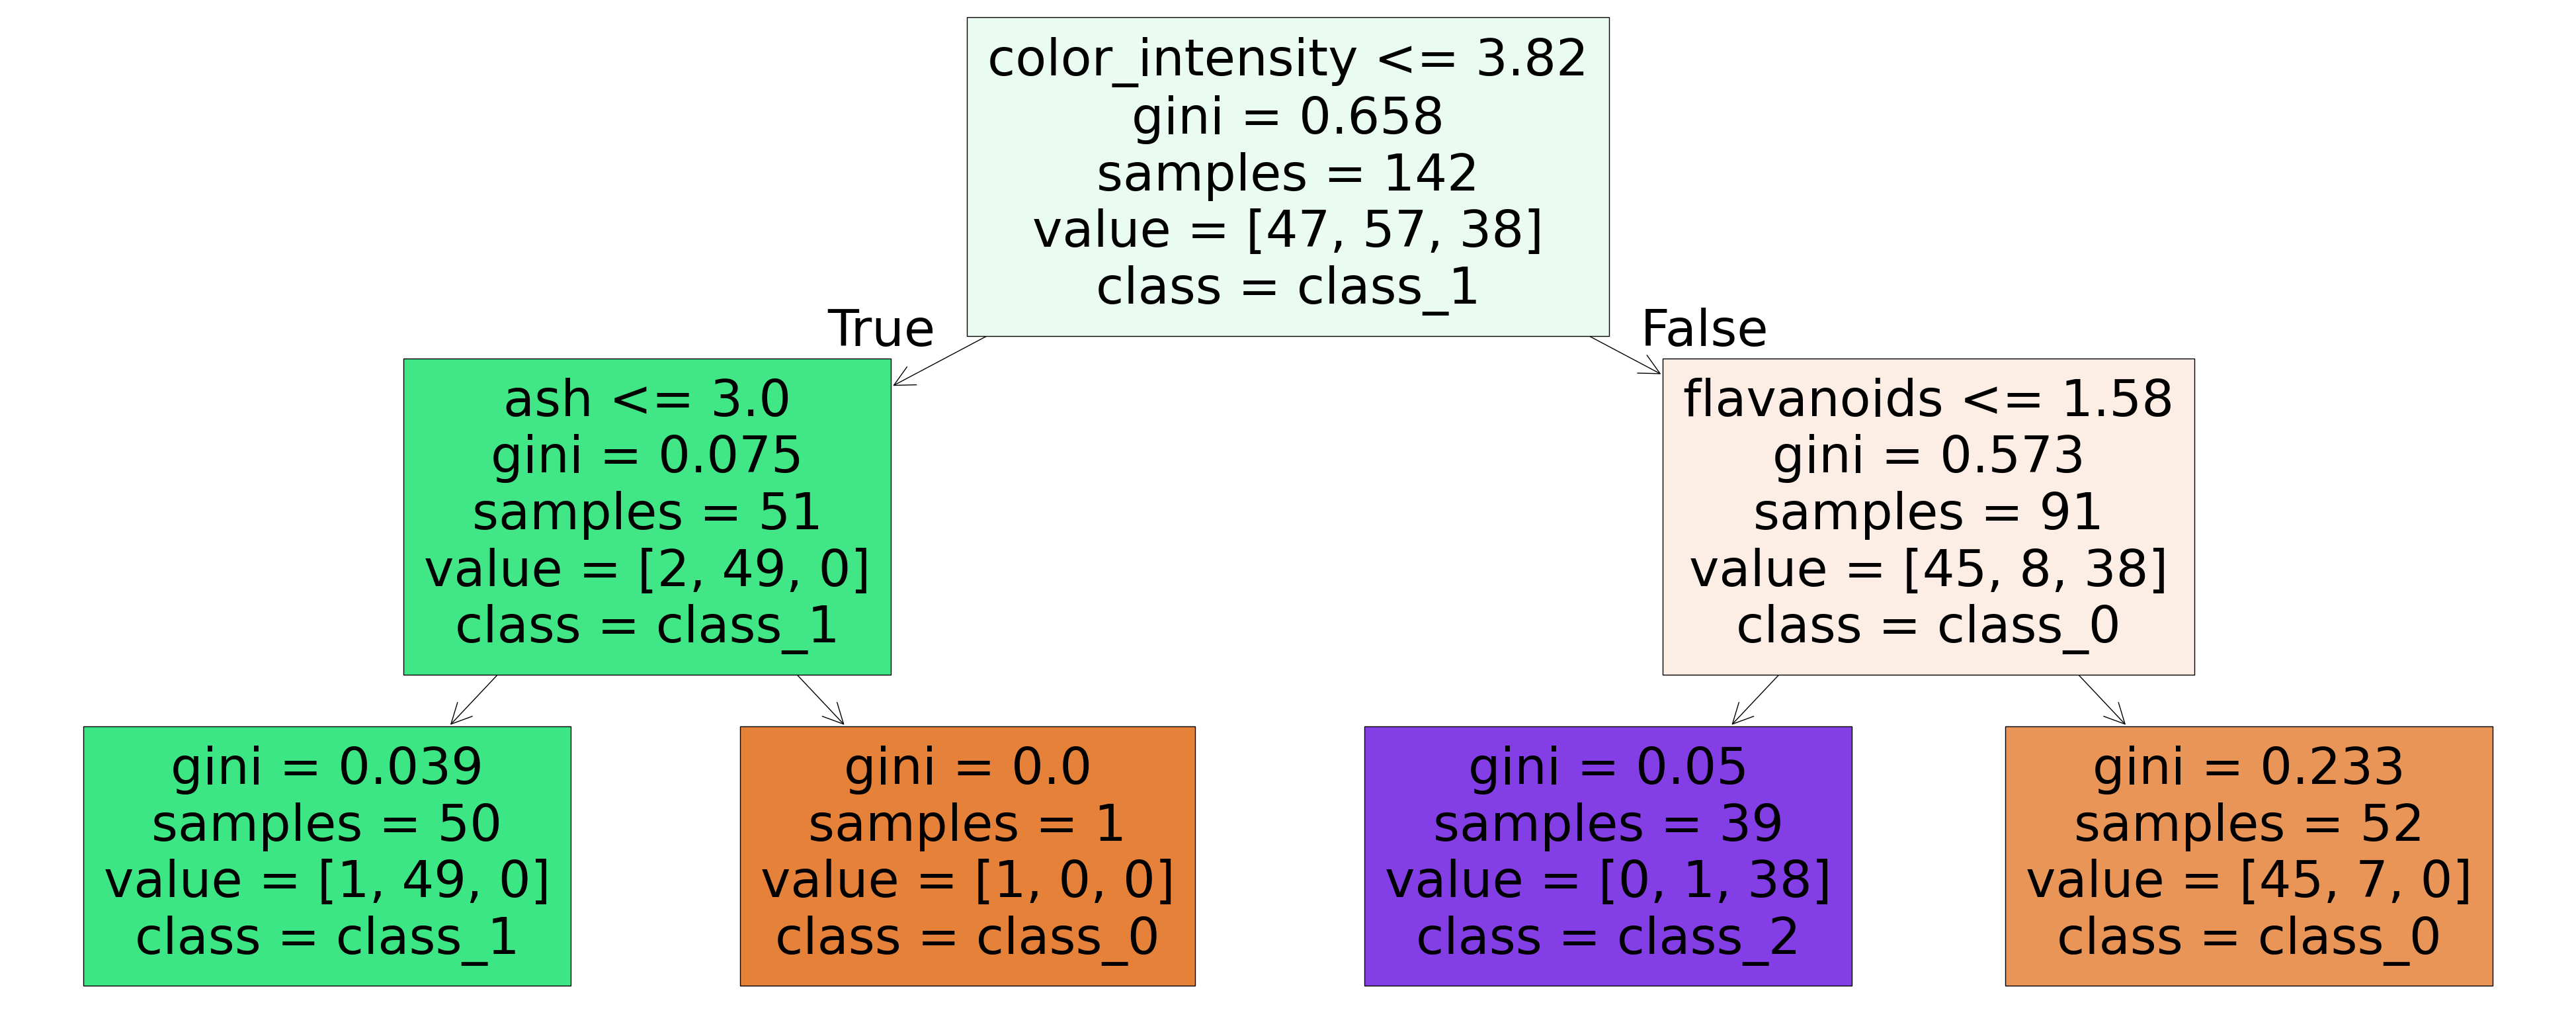

Precisión (exactitud) del modelo con 'max_depth = 2': 0.86


In [136]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=seed)

clf = DecisionTreeClassifier(max_depth = 2, random_state=seed)

clf.fit(X_train, y_train)

plt.figure(figsize=(50, 20))
plot_tree(clf, feature_names=dataset["feature_names"],
          class_names=dataset["target_names"], filled=True)
plt.show()

y_predicho = clf.predict(X_test)

print(f"Precisión (exactitud) del modelo con 'max_depth = 2': {accuracy_score(y_test, y_predicho):.2f}")

Pasos para realizar la *búsqueda en cuadrícula*:

1) Cargamos y dividimos los datos (`train_test_split`).

2) Definimos un diccionario `param_grid` con las combinaciones de hiperparámetros a probar.

3) Iteramos sobre todas las combinaciones posibles usando `ParameterGrid(param_grid)`.

4) Entrenamos y evaluamos cada modelo, almacenando el de mejor rendimiento.

Observación: 

En el parámetro `criterion` al probar con `entropy` se obtiene una precisión igual a 1, lo cual nos indica un sobreajuste del modelo, es por ello que no es incluye.

In [322]:
from sklearn.model_selection import ParameterGrid

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=seed)

param_grid = {
    "criterion": ["gini"],
    "max_depth":  [None, 1, 2, 3, 4, 5, 6], 
    "min_impurity_decrease": [0, 0.01, 0.05]
    }

best_accuracy = 0
best_model = None

for params in ParameterGrid(param_grid):
    clf = DecisionTreeClassifier(**params, random_state=seed)

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    # print(f'Parámetros: {params}, Precisión: {accuracy:.2f}')

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = clf

print(f'\nMejor precisión: {best_accuracy:.2f} con parámetros {best_model.get_params()}')


Mejor precisión: 0.94 con parámetros {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


#### Sección 6.4

**Validación cruzada**

Procedimiento:

1) Entrenar el modelo con la mejor configuración obtenida por *búsqueda en cuadrícula*.

2) Evaluarlo con `KFold`, dividiendo los datos en `k = 5` partes.

3) Guardar las precisiones y tamaños de cada fold.

4) Calcular la precisión ponderada, considerando el número de muestras en cada fold.

In [335]:
from sklearn.model_selection import KFold

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=seed)

best_params = best_model.get_params()   # Aquí ya está incluído el valor de random_state

accuracies = []
fold_sizes = []

kf = KFold(5)

for indices_t, indices_v in kf.split(X_train_valid):
    X_train = X_train_valid[indices_t]
    X_valid = X_train_valid[indices_v]
    y_train = y_train_valid[indices_t]
    y_valid = y_train_valid[indices_v]

    fold_sizes.append(len(y_valid))

    clf = DecisionTreeClassifier(**best_params)

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_valid)

    accuracy = accuracy_score(y_valid, y_pred)

    accuracies.append(accuracy)

    print(f"Fold: {len(fold_sizes)}, Precisión: {accuracy:.2f}, Tamaño: {len(y_valid)}")

# Precisión ponderada
precision_ponderada = np.average(accuracies, weights=fold_sizes)
print(f'\nPrecisión ponderada: {precision_ponderada:.2f}')

Fold: 1, Precisión: 0.93, Tamaño: 29
Fold: 2, Precisión: 0.79, Tamaño: 29
Fold: 3, Precisión: 0.89, Tamaño: 28
Fold: 4, Precisión: 0.93, Tamaño: 28
Fold: 5, Precisión: 0.93, Tamaño: 28

Precisión ponderada: 0.89


Observamos que la precisión obtenida con `ParameterGrid` (*búsqueda en cuadrícula*) es de **0.94** y la obtenida con `KFold` es de **0.89**. Veamos la razón de esta diferencia comparando ambos métodos:

- `ParameterGrid`: **Evaluación con un solo** `train_test_split`

    - El modelo solo se entrena con `X_train` y se evalúa en `X_test`

    - Si la divisón entre entrenamiento y prueba dada por `train_test_split` favorece al modelo (por casualidad) la precisión puede ser optimista. Por ejemplo, si `X_test` contiene muestras más fáciles de clasificar.

- `KFold`: **Validación cruzada**

    - Dado que estamos haciendo `KFold(5)` el modelo se entrena y evalúa **5 veces**, cada vez con un conjunto diferente de entrenamiento y validación.

    - La precisión ponderada se calcula promediando los valores en cada fold, lo que reduce el efecto de una división específica de datos. Por lo mismo, es menos propenso a resultados inflados porque el modelo ve múltiples divisiones y no depende de una sola partición aleatoria.

Con lo anterior podemos concluir que la medida obtenida con `KFold` es la más confiables.